<a href="https://colab.research.google.com/github/Ashok-Ranoji/AI-Architect-Generative-Agentic-System/blob/main/02_Sentimental_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

KeyboardInterrupt: 

In [ ]:
!nvidia-smi

Mon Feb 23 19:25:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import matplotlib.pylab as plt
import tensorflow as tf
import numpy as np
import cv2
import os

In [ ]:
img=image.load_img('/content/drive/MyDrive/Sentiment Analysis/Training/Happy/color_emoji_1.png')

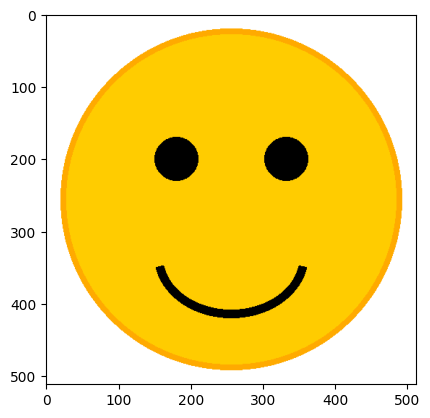

In [ ]:
plt.imshow(img)

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
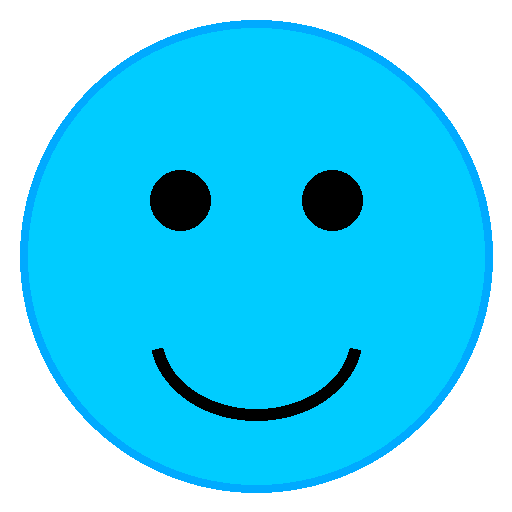

In [ ]:
i1 = cv2.imread('/content/drive/MyDrive/Sentiment Analysis/Training/Happy/color_emoji_1.png')
i1

In [ ]:
i1.shape

(512, 512, 3)

In [ ]:
train=ImageDataGenerator(rescale=1/200)
validation=ImageDataGenerator(rescale=1/200)

In [ ]:
train_dataset=train.flow_from_directory('/content/drive/MyDrive/Sentiment Analysis/Training',
                                        target_size=(200,200),
                                        batch_size=3,
                                        class_mode='binary')
validation_dataset=validation.flow_from_directory('/content/drive/MyDrive/Sentiment Analysis/Training',
                                                  target_size=(200,200),
                                                  batch_size=3,
                                                  class_mode='binary')

Found 11 images belonging to 2 classes.
Found 11 images belonging to 2 classes.


In [ ]:
train_dataset.class_indices

{'Happy': 0, 'Not Happy': 1}

In [ ]:
train_dataset.classes

array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1], dtype=int32)

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(200, 200, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 198, 198, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 99, 99, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 97, 97, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 46, 46, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    17,334,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,358,881 (66.22 MB)

 Trainable params: 17,358,881 (66.22 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss = 'binary_crossentropy',
              optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.001),
              metrics=['accuracy'])

In [ ]:
model_fit=model.fit(train_dataset,
                   steps_per_epoch=3,
                   epochs=10,
                   validation_data=validation_dataset)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.4861 - loss: 4.8660 - val_accuracy: 0.4545 - val_loss: 0.7963
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.0000e+00 - loss: 1.2813 - val_accuracy: 0.5455 - val_loss: 1.1102
Epoch 3/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.6167 - loss: 0.9766 - val_accuracy: 0.4545 - val_loss: 0.6508
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.3333 - loss: 0.6846 - val_accuracy: 0.5455 - val_loss: 0.6084
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.4542 - loss: 0.7216 - val_accuracy: 1.0000 - val_loss: 0.5353
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 1.0000 - loss: 0.5435 - val_accuracy: 1.0000 - val_loss: 0.4615
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.8958 - loss: 0.4980 - val_accuracy: 0.8182 - val_loss: 0.4073
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 1.0000 - loss: 0.2720 - val_accuracy: 0.9091 - val_loss: 0.3164
Epoch 9/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.7917 - loss: 0.3538 - val_accuracy: 0.9091 - val_loss: 0.3119
Epoch 10/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.5000 - loss: 0.6935 - val_accuracy: 1.0000 - val_loss: 0.2759


In [ ]:
dir_path =  '/content/drive/MyDrive/Sentiment Analysis/Testing'
for i in os.listdir(dir_path):
  print(i)

color_emoji_2.png
color_emoji_1.png
sad_emoji_1.png
color_emoji_3.png
sad_emoji_3.png
sad_emoji_2.png


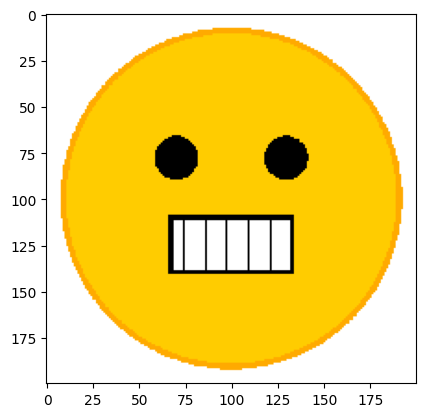

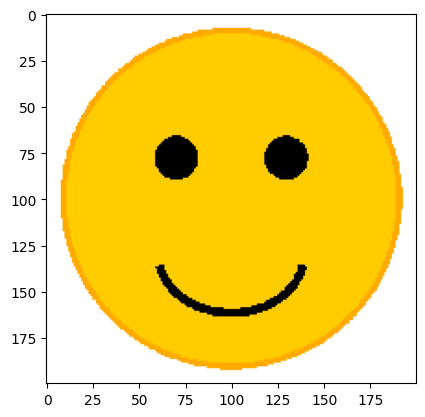

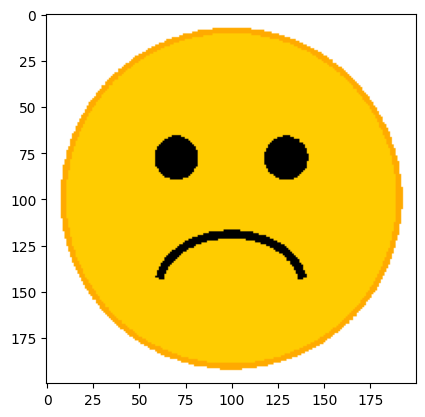

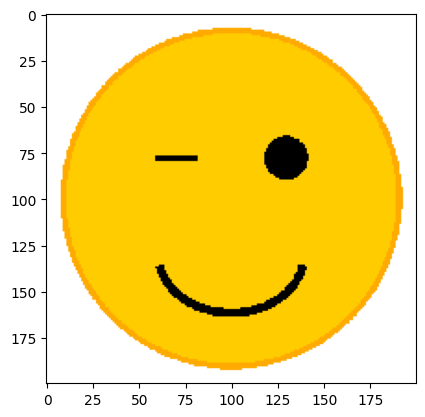

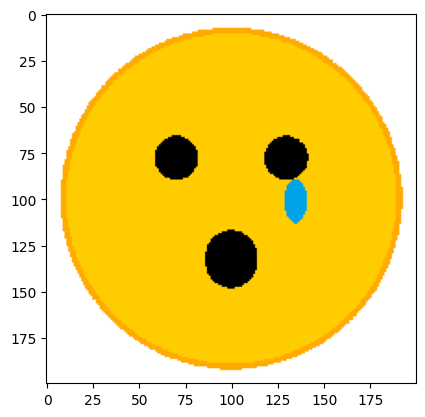

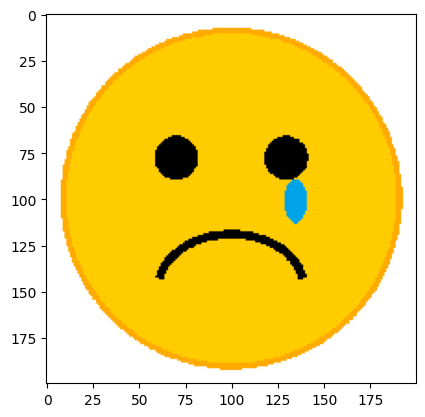

In [ ]:
dir_path =  '/content/drive/MyDrive/Sentiment Analysis/Testing'
for i in os.listdir(dir_path):
  img = image.load_img(dir_path+ '//'+i, target_size= (200,200))
  plt.imshow(img)
  plt.show(img)


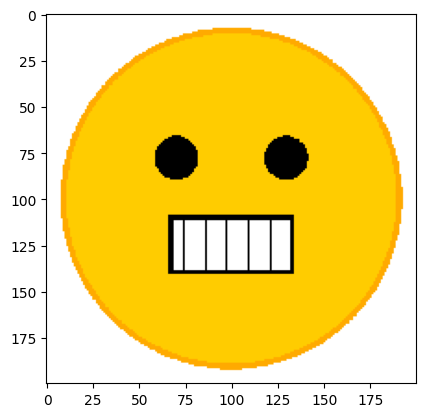

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 734ms/step
I am not Happy


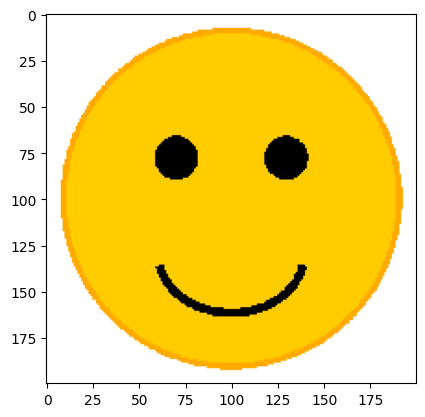

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
I am Happy


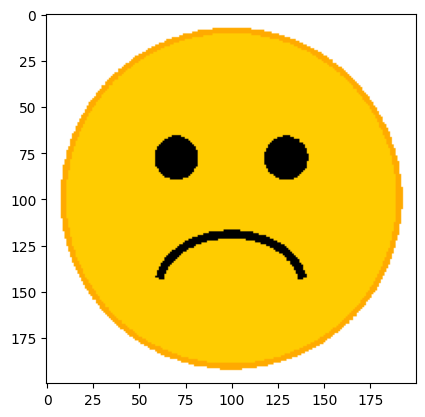

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
I am not Happy


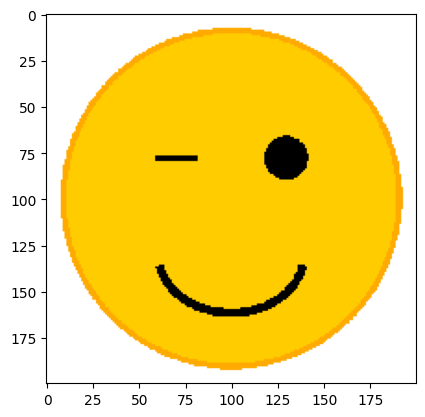

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
I am Happy


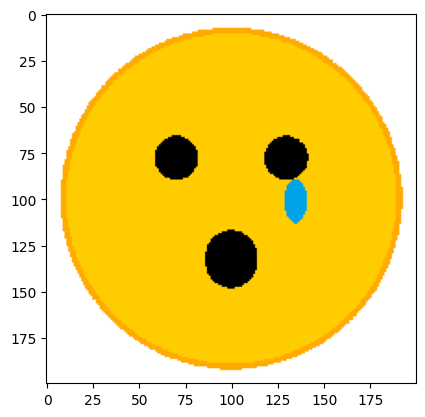

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
I am not Happy


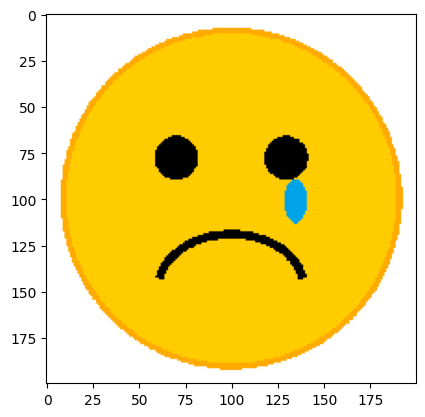

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
I am not Happy


In [ ]:
dir_path =  '/content/drive/MyDrive/Sentiment Analysis/Testing'
for i in os.listdir(dir_path):
  img = image.load_img(dir_path+ '//'+i, target_size= (200,200))
  plt.imshow(img)
  plt.show(img)

  X = image.img_to_array(img)
  X = np.expand_dims(X, axis = 0)
  images = np.vstack([X])

  val = model.predict(images)
  if val == 0:
     print ('I am Happy')
  else:
     print ('I am not Happy')

In [ ]:
## Using Gradio..
import gradio as gr
import numpy as np
from tensorflow.keras.preprocessing import image
from PIL import Image

# Load your trained model first
# model = load_model("your_model_path.h5")

def predict_mood(imga):
    # Resize image to match model input
    img = img.resize((200, 200))

    # Convert to array
    X = np.array(img)
    X = np.expand_dims(X, axis=0)

    # Prediction
    val = model.predict(X)[0][0]
    # If model outputs probability
    if val < 0.5:
        return "😊 I am Happy"
    else:
        return "😐 I am not Happy"


In [ ]:
# Gradio Interface
interface = gr.Interface(
    fn=predict_mood,
    inputs = gr.Image(type="pil", label = "Upload an Image"),
    outputs = gr.Text(label = "Predicted Mood"),
    title = "Sentiment Image Classifier",
    description="Upload an image to check if the person is Happy or Not Happy"
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f987a76d067071c406.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
!nvidia-smi

Mon Feb 23 20:30:51 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   57C    P0             28W /   70W |    1149MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----